In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv(r"\Users\Anjli Kumari\campusx-lectures\datasets\student_placement dataset.csv")

## Task 1 - Understand The Dataset

### First Five Records

In [5]:
df.head()

,CGPA,AptitudeScore,TechnicalScore,CommunicationScore,Internship,Certifications,Placed
0,7.87,50.0,84.0,57.0,1,2,1
1,7.40,81.0,99.0,51.0,1,5,1
2,7.99,98.0,49.0,56.0,0,1,1
3,8.64,82.0,78.0,83.0,0,3,1
4,7.32,47.0,60.0,57.0,1,2,0


### Number Of Rows And Columns

In [6]:
print("Number Of Rows: {}".format(df.shape[0]))
print("Number Of Columns: {}".format(df.shape[1]))

Number Of Rows: 250
Number Of Columns: 7


### Data Types Of All Attributes

In [7]:
df.dtypes

CGPA                  float64
AptitudeScore         float64
TechnicalScore        float64
CommunicationScore    float64
Internship              int64
Certifications          int64
Placed                  int64
dtype: object

### Checking Missing Values 

In [8]:
df.isnull().sum()

CGPA                  3
AptitudeScore         3
TechnicalScore        3
CommunicationScore    3
Internship            0
Certifications        0
Placed                0
dtype: int64

### Target Class Classification

In [9]:
df['Placed'].value_counts()

Placed
1    222
0     28
Name: count, dtype: int64

### Basic Statistical Information

In [10]:
df.describe()

,CGPA,AptitudeScore,TechnicalScore,CommunicationScore,Internship,Certifications,Placed
count,247.000000,247.000000,247.000000,247.000000,250.000000,250.000000,250.000000
mean,7.492267,68.218623,68.866397,70.497976,0.540000,2.044000,0.888000
std,0.715774,13.852621,14.687613,12.343615,0.499397,1.409258,0.315999
min,5.540000,30.000000,30.000000,37.000000,0.000000,0.000000,0.000000
25%,6.980000,58.000000,59.000000,62.000000,0.000000,1.000000,1.000000
50%,7.530000,68.000000,69.000000,71.000000,1.000000,2.000000,1.000000
75%,7.950000,78.000000,79.000000,78.000000,1.000000,3.000000,1.000000
max,9.500000,100.000000,100.000000,100.000000,1.000000,6.000000,1.000000


### Deliverables

#### Q.Is The Target Variable Continuous Or Categorical?
##### A.The target variable is **categorical** because it represents distinct classes (for example, Class 0 and Class 1) rather than a continuous numerical value.

#### Q.Is This A Classification Or Regression Problem?
##### A.This is a classification problem because it has two classes (Class 0 And Class 1).

#### Q.Is The Classification Binary Or Multiclass?
##### A. The Classification Is Binary.

#### Q.Are There Missing Values?
##### A.Yes,There Are Missing Values.

#### Q.Is The Target Balanced?
##### A.The Data Is Unbalanced.

In [11]:
df['Placed'].value_counts()

Placed
1    222
0     28
Name: count, dtype: int64

## Task 2 - Data Preprocessing

### Data Separation As Input And Output

In [12]:
X = df.iloc[:,0:6]
Y = df.iloc[:,-1]

In [13]:
X.head()

,CGPA,AptitudeScore,TechnicalScore,CommunicationScore,Internship,Certifications
0,7.87,50.0,84.0,57.0,1,2
1,7.40,81.0,99.0,51.0,1,5
2,7.99,98.0,49.0,56.0,0,1
3,8.64,82.0,78.0,83.0,0,3
4,7.32,47.0,60.0,57.0,1,2


### Handling Missing Values

In [14]:
X.isnull().sum()

CGPA                  3
AptitudeScore         3
TechnicalScore        3
CommunicationScore    3
Internship            0
Certifications        0
dtype: int64

In [15]:
X['CGPA'] = X['CGPA'].fillna(np.round(X['CGPA'].mean(),2))
X['AptitudeScore'] = X['AptitudeScore'].fillna(np.round(X['AptitudeScore'].mean(),2))
X['TechnicalScore'] = X['TechnicalScore'].fillna(np.round(X['TechnicalScore'].mean(),2))
X['CommunicationScore'] = X['CommunicationScore'].fillna(np.round(X['CommunicationScore'].mean(),2))

In [16]:
X.isnull().sum()

CGPA                  0
AptitudeScore         0
TechnicalScore        0
CommunicationScore    0
Internship            0
Certifications        0
dtype: int64

### Data Classification

In [17]:
X.dtypes

CGPA                  float64
AptitudeScore         float64
TechnicalScore        float64
CommunicationScore    float64
Internship              int64
Certifications          int64
dtype: object

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X.iloc[:,1] = pd.DataFrame(np.round(scaler.fit_transform(X.iloc[:,1].values.reshape(-1,1)),2))
X.iloc[:,2] = pd.DataFrame(np.round(scaler.fit_transform(X.iloc[:,2].values.reshape(-1,1)),2))
X.iloc[:,3] = pd.DataFrame(np.round(scaler.fit_transform(X.iloc[:,3].values.reshape(-1,1)),2))

In [20]:
X.head()

,CGPA,AptitudeScore,TechnicalScore,CommunicationScore,Internship,Certifications
0,7.87,-1.33,1.04,-1.10,1,2
1,7.40,0.93,2.07,-1.59,1,5
2,7.99,2.17,-1.36,-1.18,0,1
3,8.64,1.00,0.63,1.02,0,3
4,7.32,-1.54,-0.61,-1.10,1,2


In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

### Deliverables

#### Why Is Feature Scaling Important When Using Logistic Regression?
##### Feature scaling is important because Logistic Regression is sensitive to the scale of input features.

##### If one feature has values like 0–10 and another has values like 0–10000, the larger-scale feature can have a much larger influence on the model's optimization process.

##### Scaling helps by:

###### Bringing features to a similar scale
###### Making gradient descent converge faster
###### Preventing features with large numerical ranges from dominating
###### Making the coefficients easier to compare
###### Improving numerical stability

## Task 3 - Build The Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [23]:
lr.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [24]:
Y_pred = lr.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred))

0.9


In [26]:
Y_pred_proba = np.round(lr.predict_proba(X_test),2)

### Deliverables

In [27]:
res = pd.DataFrame({
    'Student' : X_test.index,
    'Actual' : Y_test,
    'Predicted' : Y_pred,
    'Predicted Probability' : Y_pred_proba.max(axis=1)
})

In [28]:
res

,Student,Actual,Predicted,Predicted Probability
142,142,1,1,0.86
6,6,1,1,0.99
97,97,1,1,0.94
60,60,1,1,0.89
112,112,1,1,0.95
181,181,0,0,0.61
197,197,1,1,0.79
184,184,1,1,0.84
9,9,1,1,0.93
104,104,1,1,0.99


## Task 4 - Classification Threshold

### Deliverables

#### What happens to the number of students classified as placed when the threshold is increased from 0.5 to 0.7?

In [29]:
print((res['Predicted Probability'] >= 0.50).sum())
print((res['Predicted Probability'] < 0.50).sum())

50
0


In [30]:
print((res['Predicted Probability'] >= 0.70).sum())
print((res['Predicted Probability'] < 0.70).sum())

43
7


## Task 5 - Evaluate The Model

In [31]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred))

0.9


In [32]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
print(cm)

[[ 2  4]
 [ 1 43]]


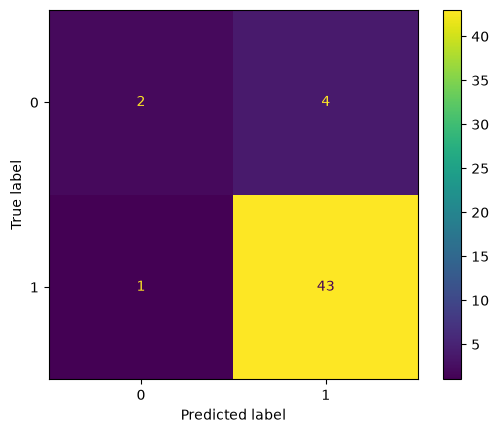

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)

In [34]:
print("True Positive: {},True Negative : {},False Positive : {} And False Negative : {}".format(cm[1][1],cm[1][0],cm[1][0],cm[0][0]))

True Positive: 43,True Negative : 1,False Positive : 1 And False Negative : 2


In [35]:
total = cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1]
print("Accuracy: {} % ".format(np.round(((cm[0][0] + cm[1][1])/total),2) * 100))
precision = np.round((cm[1][1]/(cm[1][0]+cm[1][1])),3) * 100
print("Precision: {} %".format(precision))
recall = np.round((cm[1][1]/(cm[0][1]+cm[1][1])),3) * 100
print("Recall: {} %".format(recall)) 
f1_score = np.round(((2 * precision * recall) / (precision + recall)),2)
print("F1-Score: {} %".format(f1_score))

Accuracy: 90.0 % 
Precision: 97.7 %
Recall: 91.5 %
F1-Score: 94.5 %


### Deliverables

#### Q.What Do False Positive And False Negative Mean In This Scenario?
##### A.False Positive (FP): The model predicts Class 1, but the student's actual class is Class 0.
#####   False Negative (FN): The model predicts Class 0, but the student's actual class is Class 1.

#### Q.Which Type Of Error Could Be More Concerning To The Placement Cell?
##### A. A False Negative (FN) could be more concerning if the model is used to identify students who are likely to be eligible or successful in placement opportunities.
##### A False Negative means the model predicts Class 0 for a student who actually belongs to Class 1, potentially causing an eligible student to be overlooked.

#### Q.Why May Accuraacy Alone Be Insufficient?
##### A.Accuracy alone may be insufficient because it does not show what type of errors the model is making. A model can have high accuracy but still produce many False Positives or False Negatives.
##### Therefore, metrics such as Precision, Recall, F1-score, and the Confusion Matrix should also be considered to evaluate the model properly.

## Task 6 - Model Interpretation

In [36]:
lr.coef_

array([[0.94757042, 0.3837467 , 1.31170037, 0.29304431, 0.747045  ,
        0.27711763]])

In [37]:
coefficients = []
for i in range(6):
    coefficients.append({'Feature':lr.feature_names_in_[i],
                         'Coefficient': (float)(np.round(lr.coef_[0][i],2) * 100)})

In [38]:
coefficients = pd.DataFrame(coefficients)
print("Largest Positive Coefficient:{}, {}".format(coefficients.loc[coefficients['Coefficient'].idxmax(), 'Feature'], coefficients['Coefficient'].max()))
print("Smallest Positive Coefficient:{}, {}".format(coefficients.loc[coefficients['Coefficient'].idxmin(), 'Feature'], np.round(coefficients['Coefficient'].min(),2)))

Largest Positive Coefficient:TechnicalScore, 131.0
Smallest Positive Coefficient:Certifications, 28.0


### Deliverables

#### Q.What Does A Positive Coefficient Indicate?
##### A. A positive coefficient indicates that as the value of that feature increases, the probability of the target being Class 1 increases, assuming other features remain constant.

#### Q.Can You Conclude That The Feature With The Largest Coefficient Is Always The Most Important Feature?Explain.
##### A.No. We cannot conclude that the feature with the largest coefficient is always the most important feature. The magnitude of a coefficient depends on the scale of the feature. Therefore, coefficients should ideally be compared when the features are on a similar scale, such as after standardization. Other factors, such as feature correlation, can also affect the interpretation of coefficients.

## Task 7 - Predict A New Student

In [39]:
new = [8.2,scaler.transform([[78]])[0][0],scaler.transform([[82]])[0][0],scaler.transform([[75]])[0][0],1,3]
output = lr.predict([new])
print("Output : {} ".format(output))

Output : [1] 


C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
print("Predicted Probability: {} %".format(round(lr.predict_proba([new]).max() * 100, 2)))

Predicted Probability: 99.66 %


C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Deliverables

In [41]:
probability = round(lr.predict_proba([new]).max() * 100, 2)
print("Probability Of Placement: {} ;Predicted Class: Class {}".format(probability,output[0]))

Probability Of Placement: 99.66 ;Predicted Class: Class 1


C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Task 8 - Change The Decision Threshold

In [42]:
class my_lr:
    def __init__(self,model,threshold=None):
        self.model = model
        self.threshold = threshold

    def train_test(self,X,Y,X_test,Y_test):
        self.model.fit(X,Y)
        Y_pred = self.model.predict(X_test)
        Y_pred_proba = np.round(self.model.predict_proba(X_test),2)
        res = pd.DataFrame({
            'Student': X_test.index,
            'Actual': Y_test,
            'Predicted': Y_pred,
            'Predicted Probability': np.where(Y_pred_proba.max(axis=1) >= self.threshold , "Class 1" , "Class 0")
        })
        return res

In [43]:
from sklearn.linear_model import LogisticRegression
custom_lr = my_lr(LogisticRegression(),0.7)

In [44]:
custom_lr.train_test(X,Y,X_test,Y_test)

,Student,Actual,Predicted,Predicted Probability
142,142,1,1,Class 1
6,6,1,1,Class 1
97,97,1,1,Class 1
60,60,1,1,Class 1
112,112,1,1,Class 1
181,181,0,0,Class 0
197,197,1,1,Class 1
184,184,1,1,Class 1
9,9,1,1,Class 1
104,104,1,1,Class 1


### Deliverables

#### Q.Why does the predicted class change even though the student's probability remains same?
##### A.The predicted class can change because the classification threshold has changed, not the probability.
##### For example, if the predicted probability is 0.60:
#####             Threshold = 0.50 → Class 1
#####             Threshold = 0.70 → Class 0
##### So, the student's probability remains 60%, but changing the threshold changes the predicted class.

## Task 9 - Short Summary

#### Q.Write Approximately 100-120 words answering "Can Logisitc Regression Be Considered An Appropriate Model For Predicting Student Performance In This Scenario? Discuss Its Advantages And Limitations Considering Binary Classification,Interpretability, Probability Prediction,Feature RelationShips,Decision Threshold,Dataset Size And Possible NonLinear Relationships. 

##### A.Yes, Logistic Regression can be considered an appropriate model for predicting student performance when the target is binary, such as Class 0 and Class 1. It is simple, computationally efficient, and highly interpretable. It provides probability predictions, and the decision threshold can be adjusted according to the requirement. It works well with small or medium-sized datasets and when the relationship between features and the log-odds of the target is approximately linear. However, it may struggle with complex non-linear relationships between features and student performance. Its performance can also be affected by multicollinearity, outliers, and class imbalance. Therefore, Logistic Regression is a suitable baseline model, but other models should also be considered for comparison.